# lineitem - Experiment 6: Heatmap Analysis (Exp6 vs Exp1)


In [169]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration
LOG_DIR = './result'
OUTPUT_DIR = './exp6_output'


# ==========================================
# PLOTTING
# ==========================================
plt.style.use('../../logs/custom_plt_style.mplstyle')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 1. Log File Parser

In [170]:
def parse_log_file(filepath):
    """Parse a single log file and extract all metrics including detailed I/O."""
    filename = os.path.basename(filepath)
    
    # Parse filename to extract experiment parameters
    exp_match = re.search(r'(Exp\d+\.?\d*)', filename)  # Support Exp3.1 format
    thr_match = re.search(r'Thr(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)
    imb_match = re.search(r'Imbalance([\d.]+)', filename)
    
    if not (exp_match and thr_match and mem_match):
        return None
    
    result = {
        'experiment': exp_match.group(1),
        'threads': int(thr_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'imbalance_factor': float(imb_match.group(1)) if imb_match else None,
        'filename': filename
    }
    
    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()
        
        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )
        
        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))
        
        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))
        
        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))
        else:
            result['merge_passes'] = 1
        
        # Extract partition imbalance - WEIGHTED average by partition size
        # Each merge operation has 5 columns: PAvg, PMax, Imbal, Slow, Fast
        # PAvg is at positions 0, 5, 10, 15 (0-indexed)
        # Imbal is at positions 2, 7, 12, 17 (0-indexed)
        merge_section = content.split('Merge Operations Summary')[-1]
        avg_line_match = re.search(r'\[avg\]\s+([\d.\s]+)', merge_section)
        if avg_line_match:
            # Extract all numbers from the [avg] line
            numbers_str = avg_line_match.group(1).strip()
            numbers = [float(n) for n in numbers_str.split()]
            
            # Extract partition sizes and imbalance values
            partition_sizes = []
            imbalances = []
            for i in range(0, len(numbers), 5):
                if i + 2 < len(numbers):
                    partition_sizes.append(numbers[i])      # M1PAvg, M2PAvg, M3PAvg, M4PAvg
                    imbalances.append(numbers[i + 2])       # M1Imbal, M2Imbal, M3Imbal, M4Imbal
            
            # Calculate weighted average: sum(PAvg * Imbal) / sum(PAvg)
            if partition_sizes and imbalances:
                weighted_sum = sum(p * i for p, i in zip(partition_sizes, imbalances))
                total_weight = sum(partition_sizes)
                result['partition_imbalance'] = weighted_sum / total_weight
        
        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )
        
        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0
            
            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] + 
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])
    
    return result if 'total_time' in result else None


def load_all_experiments(log_dir):
    """Load all log files and organize by experiment."""
    log_files = glob.glob(os.path.join(log_dir, '*.log'))
    
    all_data = []
    for filepath in log_files:
        parsed = parse_log_file(filepath)
        if parsed:
            all_data.append(parsed)
    
    df = pd.DataFrame(all_data)
    return df


# Load all data
df_all = load_all_experiments(LOG_DIR)
print(f"Loaded {len(df_all)} experiment results")
print(f"\nExperiments found: {sorted(df_all['experiment'].unique())}")

Loaded 41 experiment results

Experiments found: ['Exp1', 'Exp2', 'Exp3', 'Exp3.1', 'Exp4', 'Exp5']


In [171]:
def parse_exp1_subexp_log(filepath):
    """Parse Exp1.1 and Exp1.2 log files with RunGen/Merge thread counts."""
    filename = os.path.basename(filepath)

    # Parse filename: Exp1.1_RunGen40_Merge16_Mem2GB.log
    exp_match = re.search(r'(Exp\d+\.\d+)', filename)
    rungen_match = re.search(r'RunGen(\d+)', filename)
    merge_match = re.search(r'Merge(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)

    if not (exp_match and rungen_match and merge_match and mem_match):
        return None

    result = {
        'experiment': exp_match.group(1),
        'rungen_threads': int(rungen_match.group(1)),
        'merge_threads': int(merge_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'filename': filename
    }

    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()

        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )

        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads_actual'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))

        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))

        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))

        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )

        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0

            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] +
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])

    return result if 'total_time' in result else None

## Exp6 vs Exp1: Combined Heatmap Analysis

Compare Exp6 (independent RunGen/Merge thread control) with Exp1 (symmetric thread configuration):
- **Exp1**: Single row where RunGen=Merge (diagonal configuration)
- **Exp6**: Full 2D grid with independent RunGen and Merge thread counts

Three heatmaps:
1. Total Time (minutes)
2. Total I/O (GB)
3. Throughput (M entries/s)

In [172]:
def parse_exp6_log(filepath):
    """Parse Exp6 log file with RunGen and Merge thread configuration."""
    filename = os.path.basename(filepath)
    
    # Parse filename: Exp6_RunGen4_Merge8_Mem2GB.log
    match = re.search(r'Exp6_RunGen(\d+)_Merge(\d+)_Mem(\d+)GB\.log', filename)
    if not match:
        return None
    
    result = {
        'experiment': 'Exp6',
        'rungen_threads': int(match.group(1)),
        'merge_threads': int(match.group(2)),
        'memory_gb': int(match.group(3)),
        'filename': filename
    }
    
    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()
        
        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'Exp6_RunGen\d+_Merge\d+_Mem\d+GB\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )
        
        if avg_match:
            result['run_size_mb'] = float(avg_match.group(1))
            result['num_runs'] = int(avg_match.group(2))
            result['gen_threads'] = int(avg_match.group(3))
            result['merge_threads_verify'] = int(avg_match.group(4))
            result['total_time'] = float(avg_match.group(5))
            result['rungen_time'] = float(avg_match.group(6))
            result['merge_time'] = float(avg_match.group(7))
            result['entries'] = int(avg_match.group(8))
            result['throughput'] = float(avg_match.group(9))
            result['read_mb'] = float(avg_match.group(10))
            result['write_mb'] = float(avg_match.group(11))
            result['total_io_mb'] = result['read_mb'] + result['write_mb']
    
    return result if 'total_time' in result else None

In [173]:
# Load Exp6 data
# Build Exp1 data for diagonal entries (RunGen=Merge)
df_exp1 = df_all[df_all['experiment'] == 'Exp1'].sort_values('threads')

exp6_files = glob.glob(os.path.join(LOG_DIR, 'Exp6_*.log'))
exp6_data = []
for f in exp6_files:
    parsed = parse_exp6_log(f)
    if parsed:
        exp6_data.append(parsed)

df_exp6 = pd.DataFrame(exp6_data)
print(f"Loaded {len(df_exp6)} Exp6 configurations")
print(f"RunGen threads: {sorted(df_exp6['rungen_threads'].unique())}")
print(f"Merge threads: {sorted(df_exp6['merge_threads'].unique())}")

# Use Exp1 data for diagonal entries (RunGen=Merge)
print(f"\nUsing existing Exp1 data: {len(df_exp1)} configurations")
print(f"Threads: {sorted(df_exp1['threads'].unique())}")

Loaded 42 Exp6 configurations
RunGen threads: [np.int64(4), np.int64(8), np.int64(16), np.int64(24), np.int64(32), np.int64(40), np.int64(44)]
Merge threads: [np.int64(4), np.int64(8), np.int64(16), np.int64(24), np.int64(32), np.int64(40), np.int64(44)]

Using existing Exp1 data: 7 configurations
Threads: [np.int64(4), np.int64(8), np.int64(16), np.int64(24), np.int64(32), np.int64(40), np.int64(44)]


In [174]:
# Create combined heatmap data for Exp6 and Exp1
# Get all unique thread values
all_threads = sorted(set(df_exp6['rungen_threads'].unique()) |
                    set(df_exp6['merge_threads'].unique()) |
                    set(df_exp1['threads'].unique()))

print(f"All thread values: {all_threads}")

# Create matrices: rows = RunGen threads, cols = Merge threads
n_rows = len(all_threads)
n_cols = len(all_threads)

total_time_matrix = np.full((n_rows, n_cols), np.nan)
total_io_matrix = np.full((n_rows, n_cols), np.nan)
throughput_matrix = np.full((n_rows, n_cols), np.nan)

# Fill Exp6 data (off-diagonal)
for _, row in df_exp6.iterrows():
    i = all_threads.index(row['rungen_threads'])
    j = all_threads.index(row['merge_threads'])
    total_time_matrix[i, j] = row['total_time']
    total_io_matrix[i, j] = row['total_io_mb']
    throughput_matrix[i, j] = row['throughput']

# Fill Exp1 data on the diagonal (where RunGen=Merge)
for _, row in df_exp1.iterrows():
    idx = all_threads.index(row['threads'])
    total_time_matrix[idx, idx] = row['total_time']
    total_io_matrix[idx, idx] = row['total_io_mb']
    throughput_matrix[idx, idx] = row['throughput']

# Convert to appropriate units
total_time_matrix_min = total_time_matrix / 60
total_io_matrix_gb = total_io_matrix / 1024

# Create row and column labels
row_labels = [str(t) for t in all_threads]
col_labels = [str(t) for t in all_threads]

print(f"Matrix shape: {n_rows} x {n_cols}")
print(f"Exp1 configurations: {np.sum(~np.isnan(total_time_matrix[np.diag_indices(n_rows)]))}")
print(f"Exp6 configurations: {np.sum(~np.isnan(total_time_matrix)) - np.sum(~np.isnan(total_time_matrix[np.diag_indices(n_rows)]))}")

All thread values: [np.int64(4), np.int64(8), np.int64(16), np.int64(24), np.int64(32), np.int64(40), np.int64(44)]
Matrix shape: 7 x 7
Exp1 configurations: 7
Exp6 configurations: 42


In [175]:
def create_combined_heatmap(data_matrix, title, cmap, unit, vmin=None, vmax=None,
                            format_str='.1f', invert=False):
    """Create a single heatmap with annotations combining Exp6 and Exp1."""
    fig, ax = plt.subplots()
    
    # Determine vmin/vmax if not provided
    if vmin is None:
        vmin = np.nanmin(data_matrix)
    if vmax is None:
        vmax = np.nanmax(data_matrix)
    
    im = ax.imshow(data_matrix, cmap=cmap, aspect='auto',
                   interpolation='nearest', origin='lower',
                   vmin=vmin, vmax=vmax)
    
    # Add text annotations
    for i in range(n_rows):
        for j in range(n_cols):
            if not np.isnan(data_matrix[i, j]):
                value = data_matrix[i, j]
                text_str = f'{value:{format_str}}'
                
                # Determine text color for readability
                norm_val = (value - vmin) / (vmax - vmin) if vmax > vmin else 0.5
                text_color = 'white' if norm_val > 0.5 else 'black'
                
                ax.text(j, i, text_str, ha="center", va="center",
                       color=text_color, fontsize=9, fontweight='bold')
    
    # Set ticks and labels
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.set_xticklabels(col_labels)
    ax.set_yticklabels(row_labels)
    ax.set_xlabel('Merge Threads')
    ax.set_ylabel('RunGen Threads')
    # ax.set_title(title, fontweight='bold', fontsize=14, pad=20)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label=unit, pad=0.02)
    cbar.ax.tick_params(labelsize=10)
    
    # Add diagonal line to highlight Exp1 data (where RunGen=Merge)
    # ax.plot([-0.5, n_cols - 0.5], [-0.5, n_rows - 0.5],
    #         color='black', linewidth=2, linestyle='--', alpha=0.5,
    #         label='Exp1 (RG=MG)')
    
    # Find and mark optimal value
    # if invert:  # For throughput, find maximum
    #     opt_idx = np.unravel_index(np.nanargmax(data_matrix), data_matrix.shape)
    #     label = 'Best'
    # else:  # For time and I/O, find minimum
    #     opt_idx = np.unravel_index(np.nanargmin(data_matrix), data_matrix.shape)
    #     label = 'Best'
    
    # ax.plot(opt_idx[1], opt_idx[0], 'b*', markersize=25, markeredgewidth=2.5,
    #         markeredgecolor='blue', markerfacecolor='none', label=label)
    # ax.legend(loc='upper right', fontsize=11)
    
    # Add grid for better readability
    ax.set_xticks(np.arange(n_cols) - 0.5, minor=True)
    ax.set_yticks(np.arange(n_rows) - 0.5, minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    
    return fig, ax

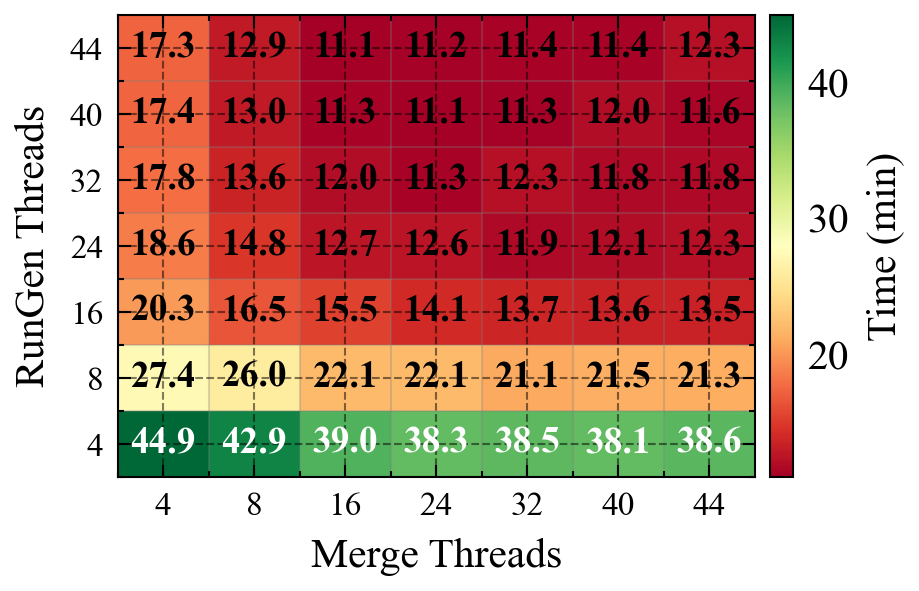

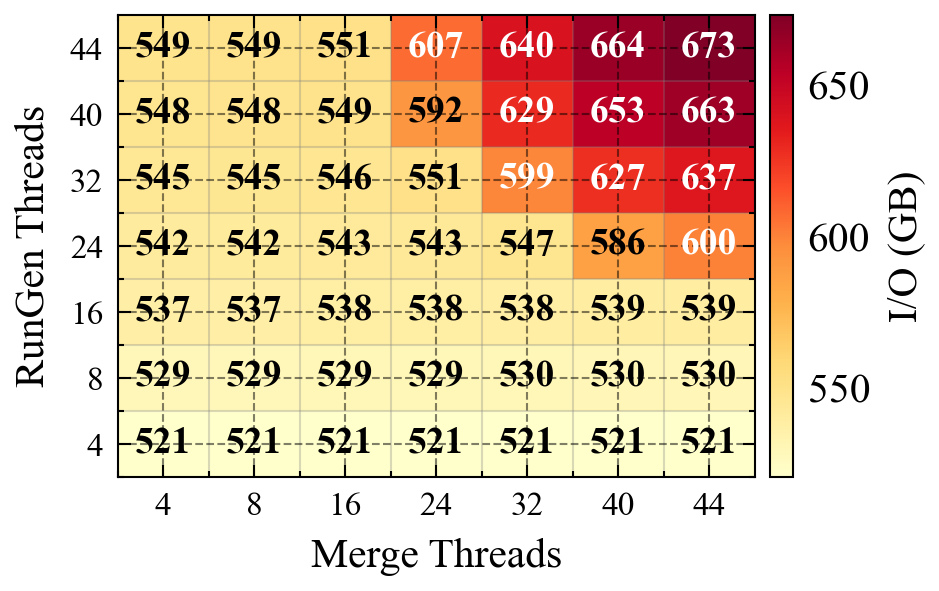

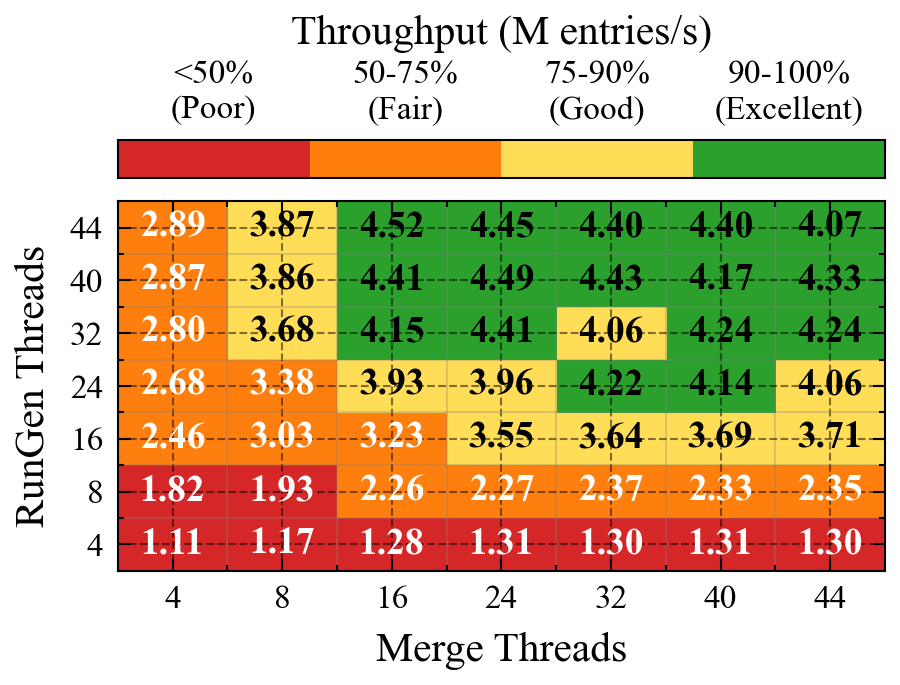

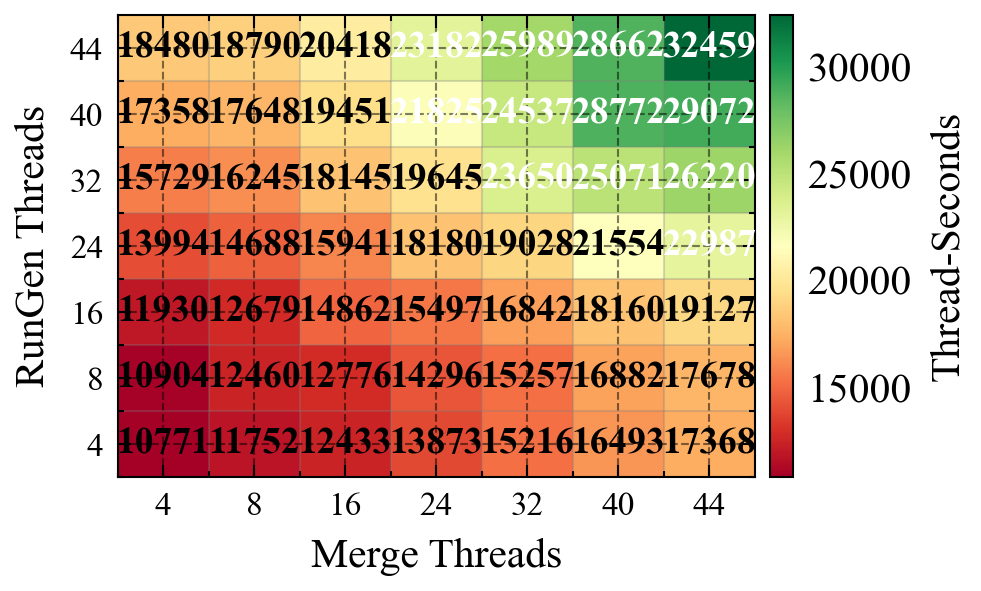

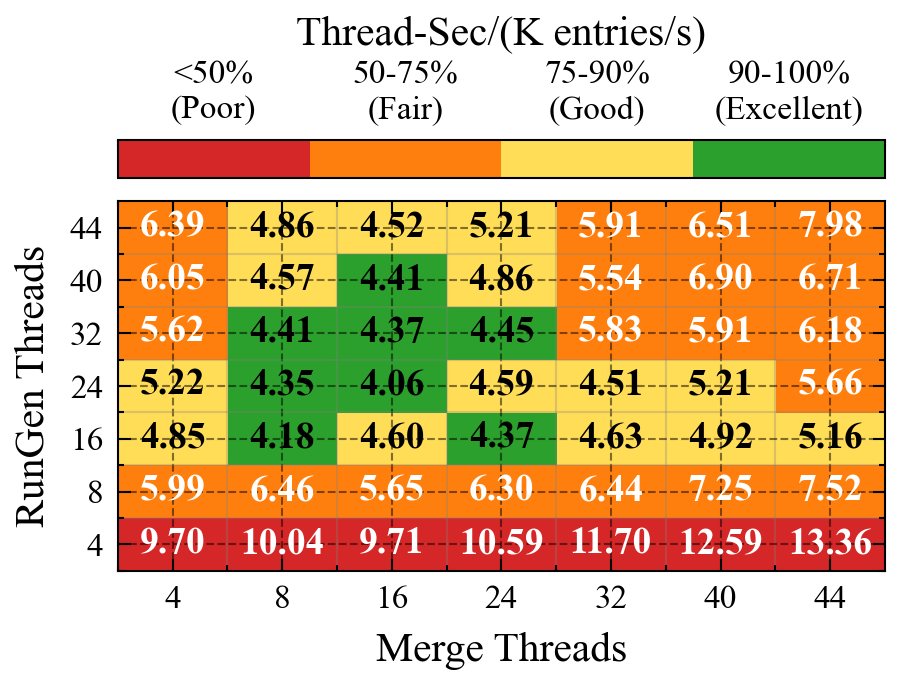

In [183]:
# 1. Total Time Heatmap
fig1, ax1 = create_combined_heatmap(
    total_time_matrix_min,
    'Exp6 vs Exp1: Total Time Comparison',
    'RdYlGn',
    'Time (min)',
    format_str='.1f'
)
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp6_exp1_total_time_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# 2. Total I/O Heatmap
fig2, ax2 = create_combined_heatmap(
    total_io_matrix_gb,
    'Exp6 vs Exp1: Total I/O Comparison',
    'YlOrRd',
    'I/O (GB)',
    format_str='.0f'
)
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp6_exp1_total_io_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# 3. Throughput Heatmap with tier-based color coding
from matplotlib.colors import BoundaryNorm, ListedColormap

# Create tier-based heatmap
fig3, ax3 = plt.subplots()

# Calculate performance tiers based on percentage of best
max_tput = np.nanmax(throughput_matrix)
throughput_tier_pct = (throughput_matrix / max_tput) * 100

# Define performance tiers (percentage of best)
# Top 10%, Top 25%, Top 50%, Below 50%
boundaries = [0, 50, 75, 90, 100]
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c']  # Red, Orange, Light Yellow, Green
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, cmap.N)

im = ax3.imshow(throughput_tier_pct, cmap=cmap, norm=norm, aspect='auto',
               interpolation='nearest', origin='lower')

# Add text annotations with actual throughput values
for i in range(n_rows):
    for j in range(n_cols):
        if not np.isnan(throughput_matrix[i, j]):
            value = throughput_matrix[i, j]
            text_str = f'{value:.2f}'

            # Determine text color based on tier
            tier_pct = throughput_tier_pct[i, j]
            if tier_pct >= 75:
                text_color = 'black'
            else:
                text_color = 'white'

            ax3.text(j, i, text_str, ha="center", va="center",
                   color=text_color, fontsize=9, fontweight='bold')

# Set ticks and labels
ax3.set_xticks(range(n_cols))
ax3.set_yticks(range(n_rows))
ax3.set_xticklabels(col_labels)
ax3.set_yticklabels(row_labels)
ax3.set_xlabel('Merge Threads')
ax3.set_ylabel('RunGen Threads')

# Add colorbar with tier labels - RELOCATED TO TOP
cbar = plt.colorbar(im, ax=ax3, location='top', label='Throughput (M entries/s)',
                   boundaries=boundaries, ticks=[25, 62.5, 82.5, 95])
cbar.ax.set_xticklabels(['<50%\n(Poor)', '50-75%\n(Fair)',
                         '75-90%\n(Good)', '90-100%\n(Excellent)'],
                        fontsize=8)

# Add grid for better readability
ax3.set_xticks(np.arange(n_cols) - 0.5, minor=True)
ax3.set_yticks(np.arange(n_rows) - 0.5, minor=True)
ax3.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp6_exp1_throughput_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# ========== NEW: Resource Cost Heatmaps ==========
# Build resource cost matrix using correct formula
resource_cost_matrix = np.full((n_rows, n_cols), np.nan)
cost_per_tput_matrix = np.full((n_rows, n_cols), np.nan)

# Fill Exp6 data with correct resource cost formula
for _, row in df_exp6.iterrows():
    i = all_threads.index(row['rungen_threads'])
    j = all_threads.index(row['merge_threads'])
    # Resource cost = (rungen_threads × rungen_time) + (merge_threads × merge_time)
    resource_cost = row['rungen_threads'] * row['rungen_time'] + row['merge_threads'] * row['merge_time']
    resource_cost_matrix[i, j] = resource_cost
    # Cost per throughput (lower is better)
    cost_per_tput_matrix[i, j] = resource_cost / (row['throughput'] * 1000)  # per K entries/s

# Fill Exp1 data on diagonal with correct resource cost formula
for _, row in df_exp1.iterrows():
    idx = all_threads.index(row['threads'])
    # Resource cost = (threads × rungen_time) + (threads × merge_time)
    resource_cost = row['threads'] * row['rungen_time'] + row['threads'] * row['merge_time']
    resource_cost_matrix[idx, idx] = resource_cost
    # Cost per throughput
    cost_per_tput_matrix[idx, idx] = resource_cost / (row['throughput'] * 1000)

# 4. Resource Cost Heatmap
fig4, ax4 = create_combined_heatmap(
    resource_cost_matrix,
    'LineItem: Resource Cost',
    'RdYlGn',
    'Thread-Seconds',
    format_str='.0f'
)
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp6_exp1_resource_cost_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# 5. Resource Cost per Throughput Heatmap with tier-based color coding
# For cost metrics, lower is better, so we invert the percentage calculation
min_cost = np.nanmin(cost_per_tput_matrix)
cost_efficiency_pct = (min_cost / cost_per_tput_matrix) * 100

# Create tier-based heatmap
fig5, ax5 = plt.subplots()

# Define performance tiers (percentage of best efficiency)
boundaries = [0, 50, 75, 90, 100]
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c']  # Red, Orange, Light Yellow, Green
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, cmap.N)

im = ax5.imshow(cost_efficiency_pct, cmap=cmap, norm=norm, aspect='auto',
               interpolation='nearest', origin='lower')

# Add text annotations with actual cost values
for i in range(n_rows):
    for j in range(n_cols):
        if not np.isnan(cost_per_tput_matrix[i, j]):
            value = cost_per_tput_matrix[i, j]
            text_str = f'{value:.2f}'

            # Determine text color based on tier
            tier_pct = cost_efficiency_pct[i, j]
            if tier_pct >= 75:
                text_color = 'black'
            else:
                text_color = 'white'

            ax5.text(j, i, text_str, ha="center", va="center",
                   color=text_color, fontsize=9, fontweight='bold')

# Set ticks and labels
ax5.set_xticks(range(n_cols))
ax5.set_yticks(range(n_rows))
ax5.set_xticklabels(col_labels)
ax5.set_yticklabels(row_labels)
ax5.set_xlabel('Merge Threads')
ax5.set_ylabel('RunGen Threads')

# Add colorbar with tier labels - RELOCATED TO TOP
cbar = plt.colorbar(im, ax=ax5, location='top', label='Thread-Sec/(K entries/s)',
                   boundaries=boundaries, ticks=[25, 62.5, 82.5, 95])
cbar.ax.set_xticklabels(['<50%\n(Poor)', '50-75%\n(Fair)',
                         '75-90%\n(Good)', '90-100%\n(Excellent)'],
                        fontsize=8)

# Add grid for better readability
ax5.set_xticks(np.arange(n_cols) - 0.5, minor=True)
ax5.set_yticks(np.arange(n_rows) - 0.5, minor=True)
ax5.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp6_exp1_cost_per_throughput_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

In [177]:
# Summary statistics
best_time_idx = np.unravel_index(np.nanargmin(total_time_matrix_min), total_time_matrix_min.shape)
best_time = total_time_matrix_min[best_time_idx]
worst_time = np.nanmax(total_time_matrix_min)

best_io_idx = np.unravel_index(np.nanargmin(total_io_matrix_gb), total_io_matrix_gb.shape)
best_io = total_io_matrix_gb[best_io_idx]
worst_io = np.nanmax(total_io_matrix_gb)

best_throughput_idx = np.unravel_index(np.nanargmax(throughput_matrix), throughput_matrix.shape)
best_throughput = throughput_matrix[best_throughput_idx]
worst_throughput = np.nanmin(throughput_matrix)

def get_config_str(idx):
    row_idx, col_idx = idx
    rg = all_threads[row_idx]
    mg = all_threads[col_idx]
    if row_idx == col_idx:  # Diagonal = Exp1
        return f"Exp1 (Threads={all_threads[row_idx]})"
    else:  # Off-diagonal = Exp6
        return f"Exp6 (RunGen={rg}, Merge={mg})"

print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

print(f"\n📊 Overall Best Configurations:")
print(f"  Best Time: {best_time:.1f} min - {get_config_str(best_time_idx)}")
print(f"  Best I/O: {best_io:.0f} GB - {get_config_str(best_io_idx)}")
print(f"  Best Throughput: {best_throughput:.2f} M entries/s - {get_config_str(best_throughput_idx)}")

print(f"\n📊 Performance Ranges:")
print(f"  Time: {best_time:.1f} - {worst_time:.1f} min (range: {worst_time/best_time:.2f}x)")
print(f"  I/O: {best_io:.0f} - {worst_io:.0f} GB (range: {worst_io/best_io:.2f}x)")
print(f"  Throughput: {worst_throughput:.2f} - {best_throughput:.2f} M entries/s (range: {best_throughput/worst_throughput:.2f}x)")

# Extract diagonal (Exp1) vs off-diagonal (Exp6)
exp1_vals = [(i, i) for i in range(n_rows) if not np.isnan(total_time_matrix_min[i, i])]
exp6_vals = [(i, j) for i in range(n_rows) for j in range(n_cols) if i != j and not np.isnan(total_time_matrix_min[i, j])]

exp1_times = [total_time_matrix_min[i, j] for i, j in exp1_vals]
exp6_times = [total_time_matrix_min[i, j] for i, j in exp6_vals]

print(f"\n📊 Exp1 (Diagonal: RunGen=Merge):")
print(f"  Best Time: {np.min(exp1_times):.1f} min")
print(f"  Worst Time: {np.max(exp1_times):.1f} min")

print(f"\n📊 Exp6 (Off-diagonal: Independent RunGen/Merge):")
print(f"  Best Time: {np.min(exp6_times):.1f} min")
print(f"  Worst Time: {np.max(exp6_times):.1f} min")
print(f"  Improvement over Exp1: {(np.min(exp1_times) - np.min(exp6_times)) / np.min(exp1_times) * 100:.1f}%")

print("\n" + "=" * 80)

SUMMARY STATISTICS

📊 Overall Best Configurations:
  Best Time: 11.1 min - Exp6 (RunGen=44, Merge=16)
  Best I/O: 521 GB - Exp1 (Threads=4)
  Best Throughput: 4.52 M entries/s - Exp6 (RunGen=44, Merge=16)

📊 Performance Ranges:
  Time: 11.1 - 44.9 min (range: 4.06x)
  I/O: 521 - 673 GB (range: 1.29x)
  Throughput: 1.11 - 4.52 M entries/s (range: 4.07x)

📊 Exp1 (Diagonal: RunGen=Merge):
  Best Time: 12.0 min
  Worst Time: 44.9 min

📊 Exp6 (Off-diagonal: Independent RunGen/Merge):
  Best Time: 11.1 min
  Worst Time: 42.9 min
  Improvement over Exp1: 7.7%



In [178]:
# Calculate efficiency matrices (percentage of optimal performance)
# For time and I/O: efficiency = optimal / actual * 100 (lower is better)
# For throughput: efficiency = actual / optimal * 100 (higher is better)

time_efficiency = (np.nanmin(total_time_matrix_min) / total_time_matrix_min) * 100
io_efficiency = (np.nanmin(total_io_matrix_gb) / total_io_matrix_gb) * 100
throughput_efficiency = (throughput_matrix / np.nanmax(throughput_matrix)) * 100

print(f"Efficiency matrices created:")
print(f"  Best time efficiency: {np.nanmax(time_efficiency):.1f}%")
print(f"  Worst time efficiency: {np.nanmin(time_efficiency):.1f}%")
print(f"  Best I/O efficiency: {np.nanmax(io_efficiency):.1f}%")
print(f"  Worst I/O efficiency: {np.nanmin(io_efficiency):.1f}%")
print(f"  Best throughput efficiency: {np.nanmax(throughput_efficiency):.1f}%")
print(f"  Worst throughput efficiency: {np.nanmin(throughput_efficiency):.1f}%")

Efficiency matrices created:
  Best time efficiency: 100.0%
  Worst time efficiency: 24.6%
  Best I/O efficiency: 100.0%
  Worst I/O efficiency: 77.4%
  Best throughput efficiency: 100.0%
  Worst throughput efficiency: 24.6%


In [179]:
# Analyze efficiency distributions
print("=" * 80)
print("EFFICIENCY ANALYSIS")
print("=" * 80)

# Count configurations by efficiency tier
def count_efficiency_tiers(efficiency_matrix):
    flat = efficiency_matrix.flatten()
    flat = flat[~np.isnan(flat)]
    
    excellent = np.sum(flat >= 90)
    good = np.sum((flat >= 75) & (flat < 90))
    fair = np.sum((flat >= 50) & (flat < 75))
    poor = np.sum(flat < 50)
    
    return excellent, good, fair, poor

time_tiers = count_efficiency_tiers(time_efficiency)
io_tiers = count_efficiency_tiers(io_efficiency)
throughput_tiers = count_efficiency_tiers(throughput_efficiency)

print(f"\n📊 Time Efficiency Distribution:")
print(f"  Excellent (90-100%): {time_tiers[0]} configurations")
print(f"  Good (75-90%):       {time_tiers[1]} configurations")
print(f"  Fair (50-75%):       {time_tiers[2]} configurations")
print(f"  Poor (<50%):         {time_tiers[3]} configurations")

print(f"\n📊 I/O Efficiency Distribution:")
print(f"  Excellent (90-100%): {io_tiers[0]} configurations")
print(f"  Good (75-90%):       {io_tiers[1]} configurations")
print(f"  Fair (50-75%):       {io_tiers[2]} configurations")
print(f"  Poor (<50%):         {io_tiers[3]} configurations")

print(f"\n📊 Throughput Efficiency Distribution:")
print(f"  Excellent (90-100%): {throughput_tiers[0]} configurations")
print(f"  Good (75-90%):       {throughput_tiers[1]} configurations")
print(f"  Fair (50-75%):       {throughput_tiers[2]} configurations")
print(f"  Poor (<50%):         {throughput_tiers[3]} configurations")

# Find acceptable configurations (>=75% efficiency)
acceptable_configs = []
for i in range(n_rows):
    for j in range(n_cols):
        if not np.isnan(time_efficiency[i, j]):
            if (time_efficiency[i, j] >= 75 and 
                io_efficiency[i, j] >= 75 and 
                throughput_efficiency[i, j] >= 75):
                rg = all_threads[i]
                mg = all_threads[j]
                config_str = f"Exp1 (Threads={rg})" if i == j else f"Exp6 (RunGen={rg}, Merge={mg})"
                acceptable_configs.append((config_str, time_efficiency[i, j], 
                                          io_efficiency[i, j], throughput_efficiency[i, j]))

print(f"\n📊 Configurations with >=75% efficiency on ALL metrics: {len(acceptable_configs)}")
print(f"\nTop 10 most efficient overall:")
acceptable_configs.sort(key=lambda x: (x[1] + x[2] + x[3]) / 3, reverse=True)
for i, (config, t_eff, io_eff, tp_eff) in enumerate(acceptable_configs[:10], 1):
    avg_eff = (t_eff + io_eff + tp_eff) / 3
    print(f"  {i}. {config}: Time={t_eff:.0f}%, I/O={io_eff:.0f}%, Throughput={tp_eff:.0f}% (Avg={avg_eff:.0f}%)")

print("\n" + "=" * 80)

EFFICIENCY ANALYSIS

📊 Time Efficiency Distribution:
  Excellent (90-100%): 15 configurations
  Good (75-90%):       12 configurations
  Fair (50-75%):       13 configurations
  Poor (<50%):         9 configurations

📊 I/O Efficiency Distribution:
  Excellent (90-100%): 36 configurations
  Good (75-90%):       13 configurations
  Fair (50-75%):       0 configurations
  Poor (<50%):         0 configurations

📊 Throughput Efficiency Distribution:
  Excellent (90-100%): 16 configurations
  Good (75-90%):       11 configurations
  Fair (50-75%):       13 configurations
  Poor (<50%):         9 configurations

📊 Configurations with >=75% efficiency on ALL metrics: 27

Top 10 most efficient overall:
  1. Exp6 (RunGen=44, Merge=16): Time=100%, I/O=95%, Throughput=100% (Avg=98%)
  2. Exp6 (RunGen=40, Merge=16): Time=98%, I/O=95%, Throughput=98% (Avg=97%)
  3. Exp6 (RunGen=32, Merge=24): Time=98%, I/O=95%, Throughput=98% (Avg=97%)
  4. Exp6 (RunGen=40, Merge=24): Time=99%, I/O=88%, Throughput=9

In [180]:
from matplotlib.colors import BoundaryNorm, ListedColormap

def create_binned_heatmap(data_matrix, title, unit, format_str='.0f'):
    """Create a binned heatmap with discrete color tiers."""
    fig, ax = plt.subplots()
    
    # Define performance tiers
    boundaries = [0, 50, 75, 90, 100]
    colors = ['#d62728', '#ff7f0e', '#ffff00', '#2ca02c']  # Red, Orange, Yellow, Green
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(boundaries, cmap.N)
    
    im = ax.imshow(data_matrix, cmap=cmap, norm=norm, aspect='auto',
                   interpolation='nearest', origin='lower')
    
    # Add text annotations
    for i in range(n_rows):
        for j in range(n_cols):
            if not np.isnan(data_matrix[i, j]):
                value = data_matrix[i, j]
                text_str = f'{value:{format_str}}'
                
                # Determine text color based on tier
                if value >= 75:
                    text_color = 'black'
                else:
                    text_color = 'white'
                
                ax.text(j, i, text_str, ha="center", va="center",
                       color=text_color, fontsize=9, fontweight='bold')
    
    # Set ticks and labels
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticklabels(row_labels, fontsize=10)
    ax.set_xlabel('Merge Threads', fontweight='bold', fontsize=12)
    ax.set_ylabel('RunGen Threads', fontweight='bold', fontsize=12)
    # ax.set_title(title, fontweight='bold', fontsize=14, pad=20)
    
    # Add colorbar with tier labels
    cbar = plt.colorbar(im, ax=ax, label=unit, pad=0.02,
                       boundaries=boundaries, ticks=[25, 62.5, 82.5, 95])
    cbar.ax.set_yticklabels(['Poor\n(<50%)', 'Fair\n(50-75%)',
                             'Good\n(75-90%)', 'Excellent\n(90-100%)'],
                            fontsize=10)
    
    # Add diagonal line
    # ax.plot([-0.5, n_cols - 0.5], [-0.5, n_rows - 0.5],
    #         color='black', linewidth=2, linestyle='--', alpha=0.5,
    #         label='Exp1 (RG=MG)')
    
    # Find and mark optimal
    # opt_idx = np.unravel_index(np.nanargmax(data_matrix), data_matrix.shape)
    # ax.plot(opt_idx[1], opt_idx[0], 'b*', markersize=25, markeredgewidth=2.5,
    #         markeredgecolor='blue', markerfacecolor='none', label='Best')
    # ax.legend(loc='upper right', fontsize=11)
    
    # Add grid
    ax.set_xticks(np.arange(n_cols) - 0.5, minor=True)
    ax.set_yticks(np.arange(n_rows) - 0.5, minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    
    return fig, ax

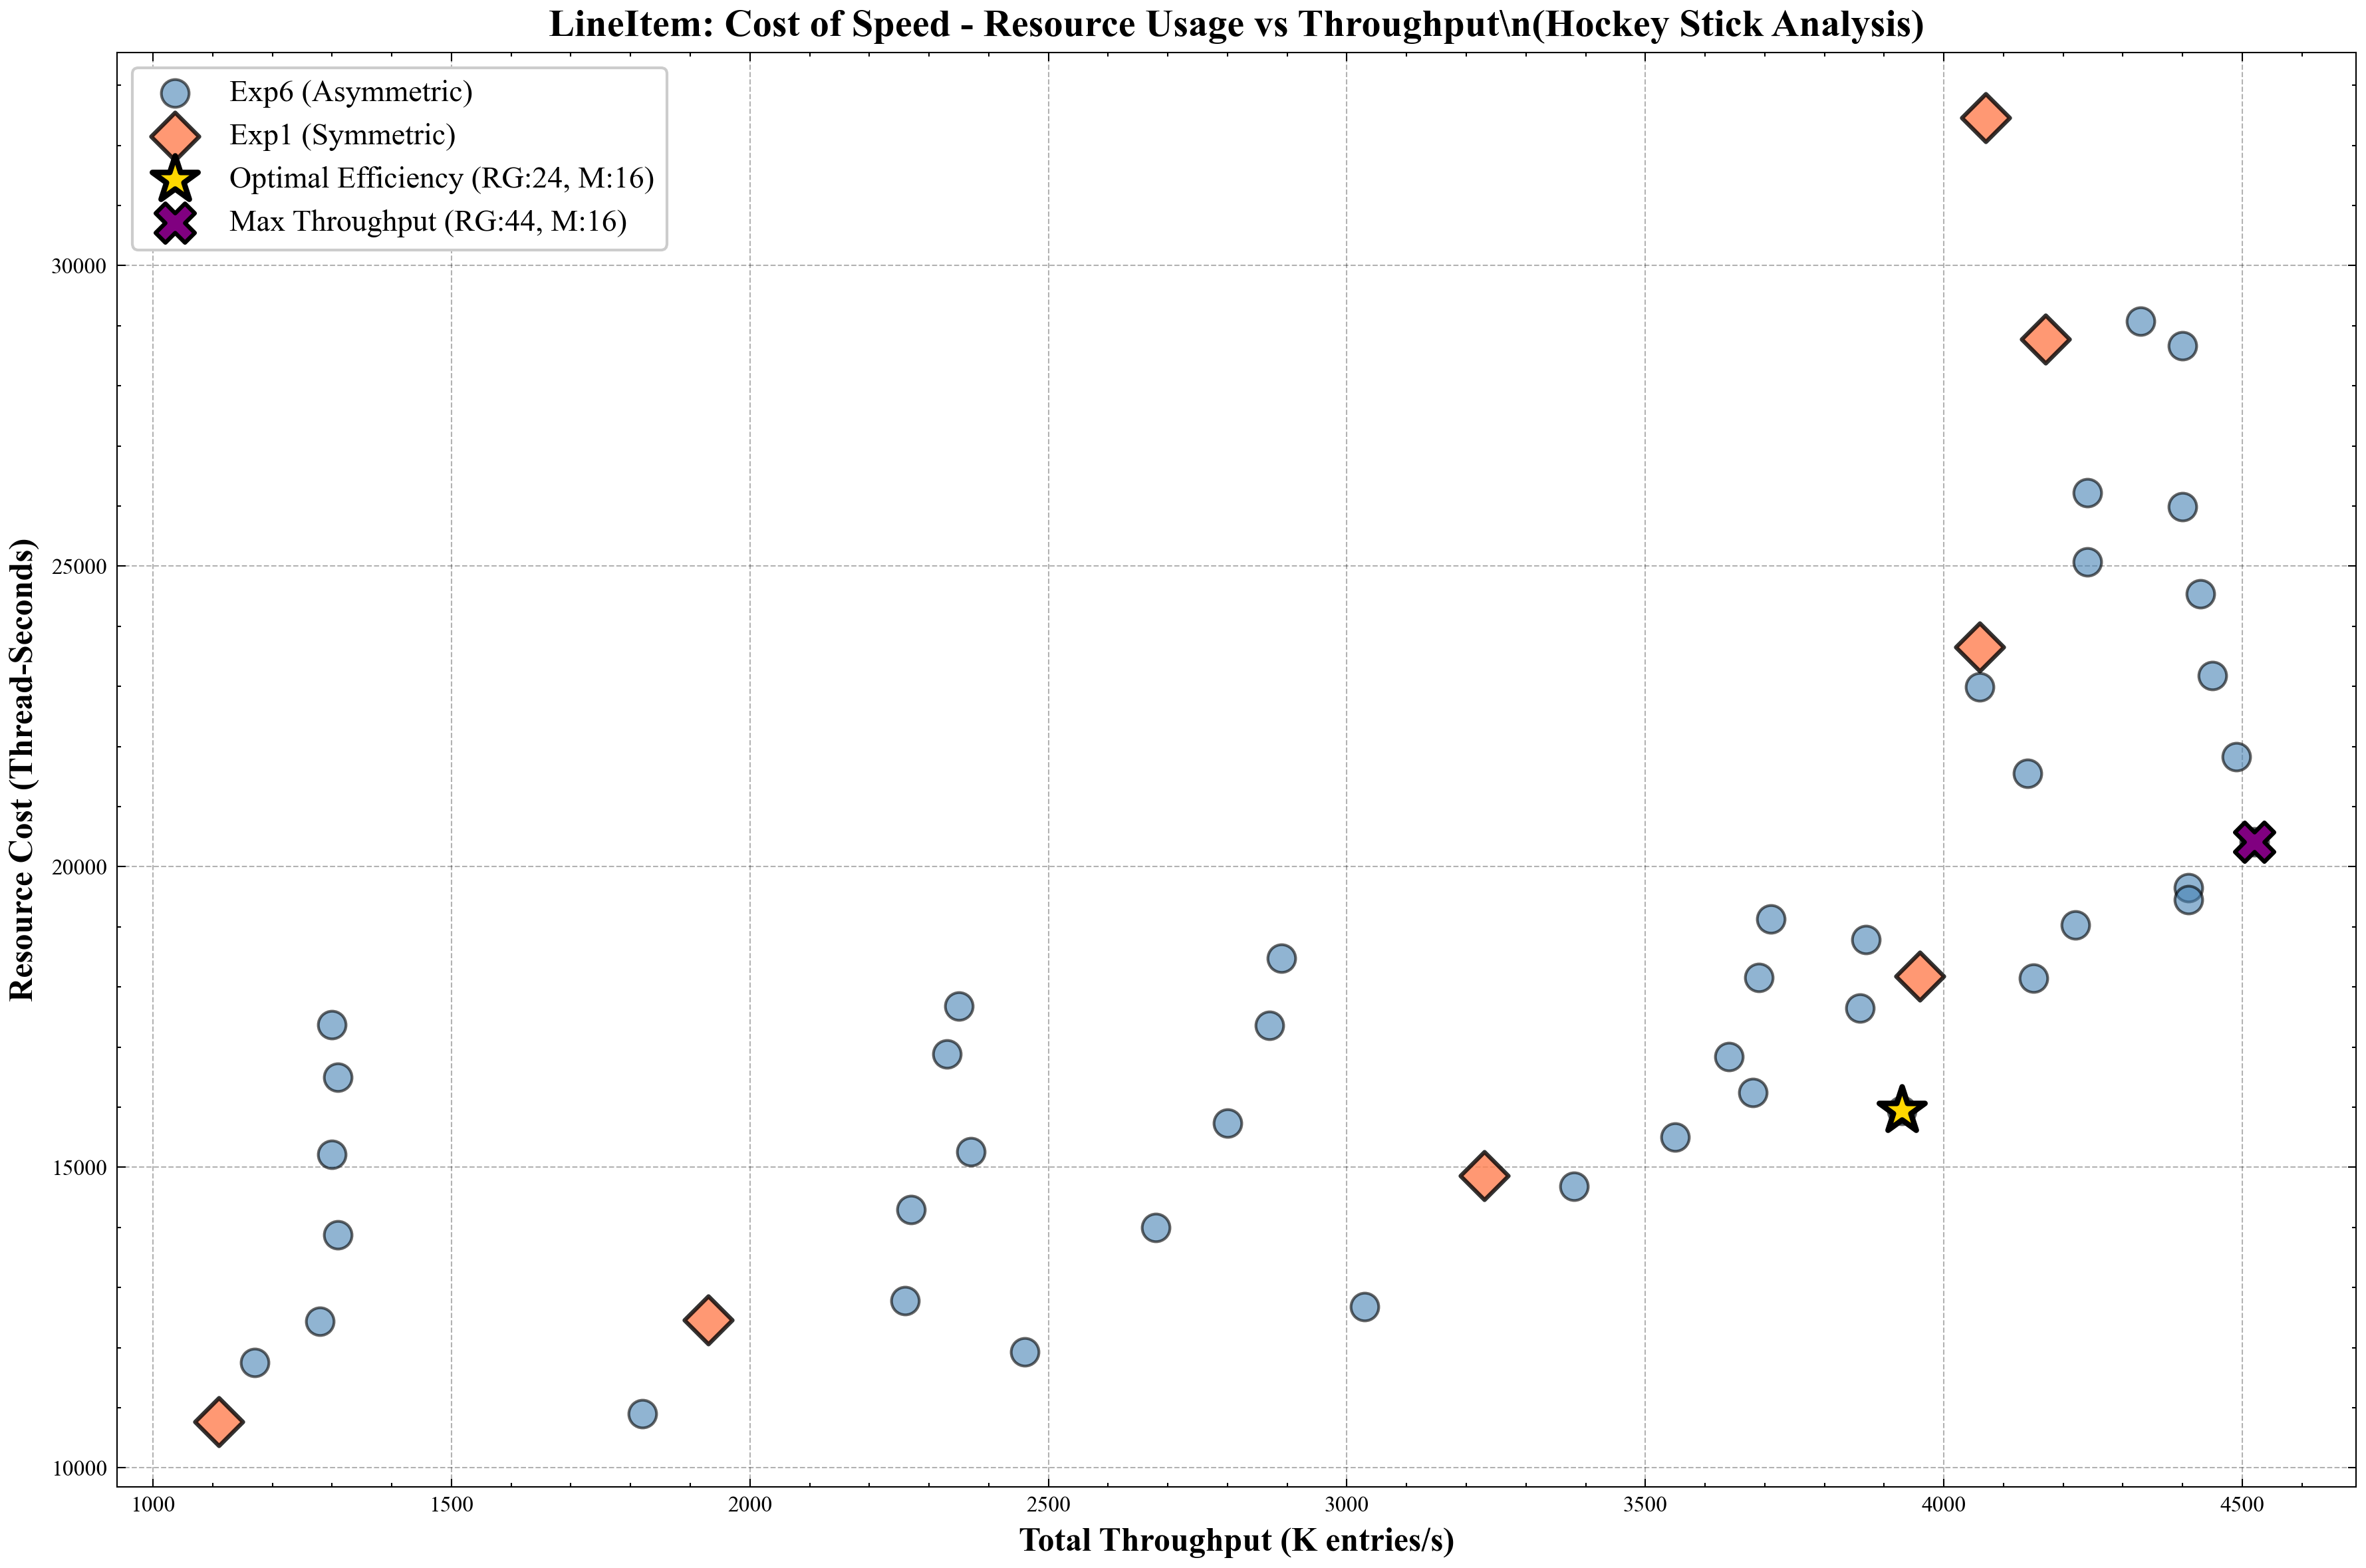

\n📊 LineItem Exp6 Marginal Gain Analysis:\n
Optimal Efficiency Point:
  - Config: RunGen 24, Merge 16 (Exp6)
  - Throughput: 3930.0K entries/s
  - Resource Cost: 15941 thread-seconds
  - Efficiency: 0.247 K entries/s per thread-second
\nMax Throughput Point:
  - Config: RunGen 44, Merge 16 (Exp6)
  - Throughput: 4520.0K entries/s
  - Resource Cost: 20418 thread-seconds
  - Efficiency: 0.221 K entries/s per thread-second
\nCost of Max Speed:
  - Cost multiplier: 1.28x
  - Throughput gain: 15.0%
  - Paying 1.3x more resources for 15.0% more speed
\n\n🔍 Configurations with Lowest Resource Costs:\n
Rank   Exp    RG    Merge  RGTime   MgTime   Tput(K)    Cost       Efficiency  
------------------------------------------------------------------------------------------
43     Exp1   4     4      2107.5   585.2    1110.0     10771      0.1031      
23     Exp6   8     4      1081.3   563.4    1820.0     10904      0.1669      
36     Exp6   4     8      2207.3   365.3    1170.0     11752      

In [181]:
# Prepare data for marginal gain analysis
# Calculate resource cost CORRECTLY: (rungen_threads × rungen_time) + (merge_threads × merge_time)
df_exp6['resource_cost'] = (df_exp6['rungen_threads'] * df_exp6['rungen_time'] + 
                             df_exp6['merge_threads'] * df_exp6['merge_time'])
df_exp6['throughput_k'] = df_exp6['throughput'] * 1000  # Convert to K entries/s

# Also add Exp1 data for comparison with correct resource cost
df_exp1['resource_cost'] = (df_exp1['threads'] * df_exp1['rungen_time'] + 
                             df_exp1['threads'] * df_exp1['merge_time'])
df_exp1['throughput_k'] = df_exp1['throughput'] * 1000

# Create scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Exp6 data
scatter_exp6 = ax.scatter(df_exp6['throughput_k'], df_exp6['resource_cost'], 
                          s=100, alpha=0.6, c='steelblue', edgecolors='black', linewidth=1,
                          label='Exp6 (Asymmetric)')

# Plot Exp1 data
scatter_exp1 = ax.scatter(df_exp1['throughput_k'], df_exp1['resource_cost'],
                          s=150, alpha=0.8, c='coral', marker='D', edgecolors='black', linewidth=1.5,
                          label='Exp1 (Symmetric)')

# Find and mark the optimal point (best throughput per resource cost)
df_all_configs = pd.concat([
    df_exp6[['throughput_k', 'resource_cost', 'rungen_threads', 'merge_threads', 'rungen_time', 'merge_time']].assign(exp='Exp6'),
    df_exp1[['throughput_k', 'resource_cost', 'rungen_time', 'merge_time']].assign(
        exp='Exp1', 
        rungen_threads=df_exp1['threads'], 
        merge_threads=df_exp1['threads']
    )
], ignore_index=True)

# Calculate efficiency (throughput / resource_cost)
df_all_configs['efficiency'] = df_all_configs['throughput_k'] / df_all_configs['resource_cost']
optimal_idx = df_all_configs['efficiency'].idxmax()

# Extract scalar values
opt_rg = int(df_all_configs.loc[optimal_idx, 'rungen_threads'])
opt_mg = int(df_all_configs.loc[optimal_idx, 'merge_threads'])
opt_tput = float(df_all_configs.loc[optimal_idx, 'throughput_k'])
opt_cost = float(df_all_configs.loc[optimal_idx, 'resource_cost'])
opt_exp = str(df_all_configs.loc[optimal_idx, 'exp'])
opt_eff = float(df_all_configs.loc[optimal_idx, 'efficiency'])

ax.scatter([opt_tput], [opt_cost], 
           s=300, marker='*', color='gold', edgecolor='black', linewidth=2, zorder=5,
           label=f'Optimal Efficiency (RG:{opt_rg}, M:{opt_mg})')

# Find max throughput point
max_tput_idx = df_all_configs['throughput_k'].idxmax()

# Extract scalar values
max_rg = int(df_all_configs.loc[max_tput_idx, 'rungen_threads'])
max_mg = int(df_all_configs.loc[max_tput_idx, 'merge_threads'])
max_tput = float(df_all_configs.loc[max_tput_idx, 'throughput_k'])
max_cost = float(df_all_configs.loc[max_tput_idx, 'resource_cost'])
max_exp = str(df_all_configs.loc[max_tput_idx, 'exp'])
max_eff = float(df_all_configs.loc[max_tput_idx, 'efficiency'])

ax.scatter([max_tput], [max_cost], 
           s=200, marker='X', color='purple', edgecolor='black', linewidth=1.5, zorder=5,
           label=f'Max Throughput (RG:{max_rg}, M:{max_mg})')

ax.set_xlabel('Total Throughput (K entries/s)', fontweight='bold', fontsize=12)
ax.set_ylabel('Resource Cost (Thread-Seconds)', fontweight='bold', fontsize=12)
ax.set_title('LineItem: Cost of Speed - Resource Usage vs Throughput\\n(Hockey Stick Analysis)', 
             fontweight='bold', fontsize=14)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp6_marginal_gain_scatter.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print analysis
print("\\n📊 LineItem Exp6 Marginal Gain Analysis:\\n")
print(f"Optimal Efficiency Point:")
print(f"  - Config: RunGen {opt_rg}, Merge {opt_mg} ({opt_exp})")
print(f"  - Throughput: {opt_tput:.1f}K entries/s")
print(f"  - Resource Cost: {opt_cost:.0f} thread-seconds")
print(f"  - Efficiency: {opt_eff:.3f} K entries/s per thread-second")
print(f"\\nMax Throughput Point:")
print(f"  - Config: RunGen {max_rg}, Merge {max_mg} ({max_exp})")
print(f"  - Throughput: {max_tput:.1f}K entries/s")
print(f"  - Resource Cost: {max_cost:.0f} thread-seconds")
print(f"  - Efficiency: {max_eff:.3f} K entries/s per thread-second")
print(f"\\nCost of Max Speed:")
cost_multiplier = max_cost / opt_cost
tput_gain = (max_tput / opt_tput - 1) * 100
print(f"  - Cost multiplier: {cost_multiplier:.2f}x")
print(f"  - Throughput gain: {tput_gain:.1f}%")
print(f"  - Paying {cost_multiplier:.1f}x more resources for {tput_gain:.1f}% more speed")

# Print configurations with lowest resource costs
print("\\n\\n🔍 Configurations with Lowest Resource Costs:\\n")
print("=" * 90)
df_sorted_by_cost = df_all_configs.sort_values('resource_cost')
print(f"{'Rank':<6} {'Exp':<6} {'RG':<5} {'Merge':<6} {'RGTime':<8} {'MgTime':<8} {'Tput(K)':<10} {'Cost':<10} {'Efficiency':<12}")
print("-" * 90)
for i, row in df_sorted_by_cost.head(10).iterrows():
    print(f"{i+1:<6} {row['exp']:<6} {int(row['rungen_threads']):<5} {int(row['merge_threads']):<6} "
          f"{row['rungen_time']:<8.1f} {row['merge_time']:<8.1f} {row['throughput_k']:<10.1f} "
          f"{row['resource_cost']:<10.0f} {row['efficiency']:<12.4f}")